
=== RESULTADOS DA ANÁLISE (EXCENTRICIDADE + EULER-BERNOULLI) ===
Reação Apoio Esq (Ry): 90.00 kN
Reação Apoio Dir (Ry): 90.00 kN
Deflexão Máx. Real   : -1.239 mm



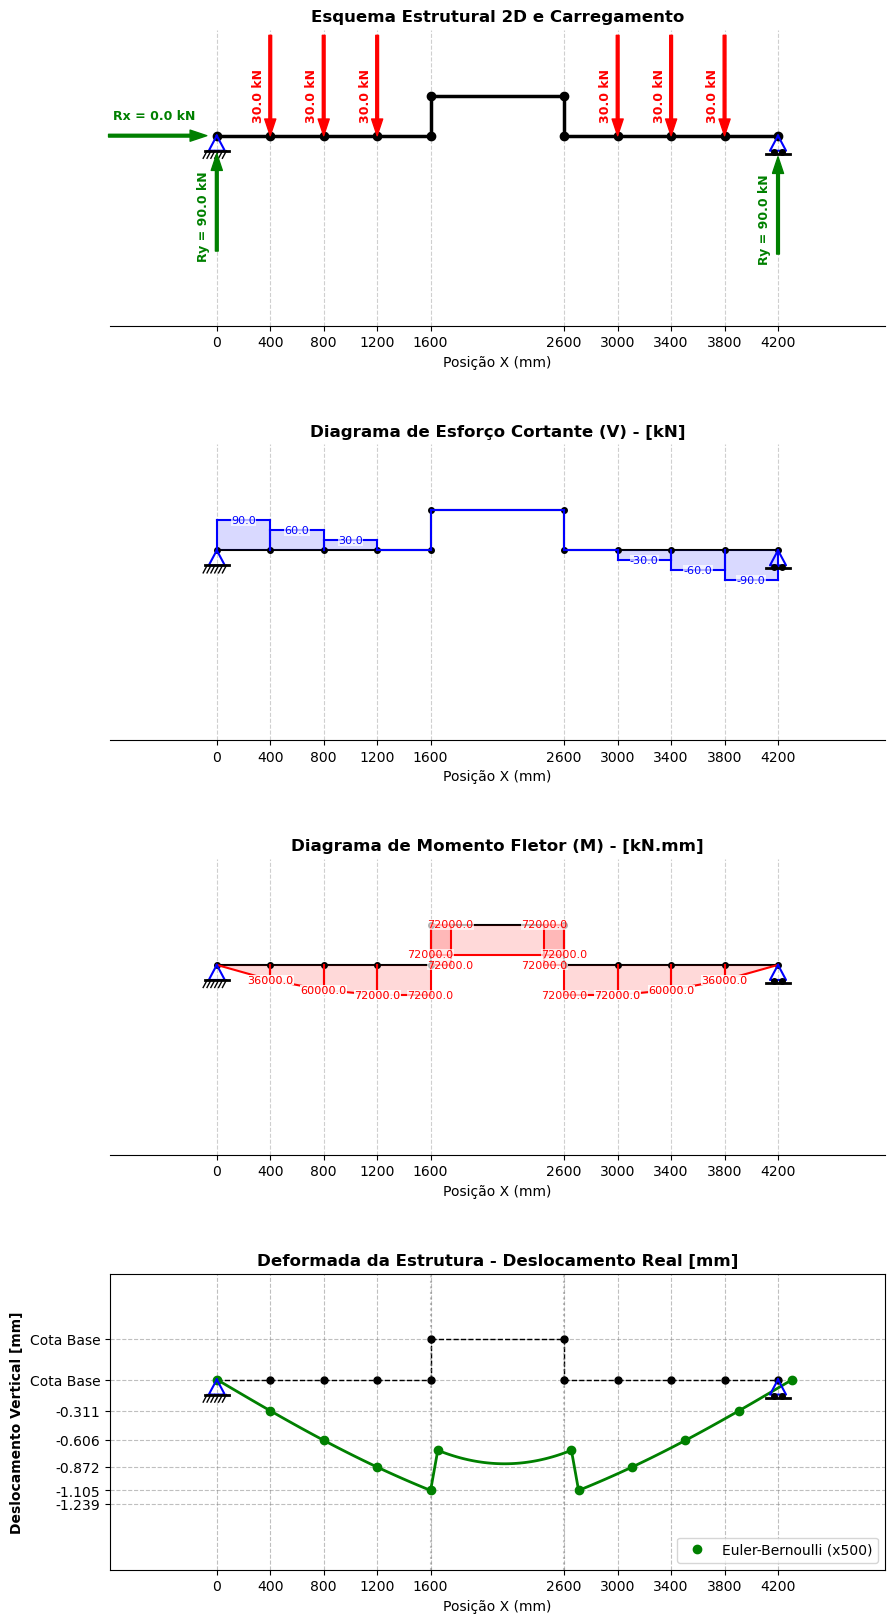

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================================================
# 1. PARÂMETROS E PROPRIEDADES (Unidades: kN, mm)
# =========================================================
E = 200.0  # Módulo de Elasticidade em kN/mm² (200000 MPa)

# Propriedades do Tramo A (Extremidades)
I_A = 1653007211.6245 
A_A = 17388.0  

# Propriedades do Tramo B (Centro com Degrau)
I_B = 334482563.4911  
A_B = 12308.0

# Propriedades dos Braços Rígidos Virtuais
I_Rig = I_A * 10000.0
A_Rig = A_A * 10000.0

# Geometria do Pórtico (Nós em X, Y)
nos_portico = np.array([
    [0, 0],       # Nó 0
    [400, 0],     # Nó 1
    [800, 0],     # Nó 2
    [1200, 0],    # Nó 3
    [1600, 0],    # Nó 4 (Base braço esquerdo)
    [1600, 200],  # Nó 5 (Topo braço esquerdo)
    [2600, 200],  # Nó 6 (Topo braço direito)
    [2600, 0],    # Nó 7 (Base braço direito)
    [3000, 0],    # Nó 8
    [3400, 0],    # Nó 9
    [3800, 0],    # Nó 10
    [4200, 0]     # Nó 11
], dtype=float)

n_nos = len(nos_portico)
n_gl = n_nos * 3  

# Elementos: [nó_i, nó_j, A, I]
elementos_portico = [
    [0, 1, A_A, I_A],        # 0: Tramo A
    [1, 2, A_A, I_A],        # 1: Tramo A
    [2, 3, A_A, I_A],        # 2: Tramo A
    [3, 4, A_A, I_A],        # 3: Tramo A
    [4, 5, A_Rig, I_Rig],    # 4: Braço Esq
    [5, 6, A_B, I_B],        # 5: Tramo B (Meio)
    [6, 7, A_Rig, I_Rig],    # 6: Braço Dir
    [7, 8, A_A, I_A],        # 7: Tramo A
    [8, 9, A_A, I_A],        # 8: Tramo A
    [9, 10, A_A, I_A],       # 9: Tramo A
    [10, 11, A_A, I_A]       # 10: Tramo A
]

# =========================================================
# 2. MONTAGEM DA MATRIZ GLOBAL (EULER-BERNOULLI)
# =========================================================
K_global = np.zeros((n_gl, n_gl))
F_global = np.zeros(n_gl)

def matriz_rigidez_portico_euler(E, A, I, dx, dy):
    L = np.hypot(dx, dy)
    c = dx / L
    s = dy / L
    
    k_loc = np.zeros((6, 6))
    
    # Esforços Axiais
    k_loc[0,0] = k_loc[3,3] = E*A/L
    k_loc[0,3] = k_loc[3,0] = -E*A/L
    
    # Esforços de Flexão (Euler-Bernoulli)
    k_loc[1,1] = k_loc[4,4] = 12*E*I/L**3
    k_loc[1,4] = k_loc[4,1] = -12*E*I/L**3
    k_loc[2,2] = k_loc[5,5] = 4*E*I/L
    k_loc[2,5] = k_loc[5,2] = 2*E*I/L
    k_loc[1,2] = k_loc[2,1] = k_loc[1,5] = k_loc[5,1] = 6*E*I/L**2
    k_loc[4,2] = k_loc[2,4] = k_loc[4,5] = k_loc[5,4] = -6*E*I/L**2
    
    T = np.zeros((6, 6))
    T[0,0] = c;  T[0,1] = s; T[1,0] = -s; T[1,1] = c; T[2,2] = 1
    T[3,3] = c;  T[3,4] = s; T[4,3] = -s; T[4,4] = c; T[5,5] = 1
    
    return T.T @ k_loc @ T

for el in elementos_portico:
    no_i, no_j, A_el, I_el = el
    dx = nos_portico[no_j, 0] - nos_portico[no_i, 0]
    dy = nos_portico[no_j, 1] - nos_portico[no_i, 1]
    
    K_el = matriz_rigidez_portico_euler(E, A_el, I_el, dx, dy)
    gls = [3*no_i, 3*no_i+1, 3*no_i+2, 3*no_j, 3*no_j+1, 3*no_j+2]
    
    for i in range(6):
        for j in range(6):
            K_global[gls[i], gls[j]] += K_el[i, j]

nos_com_carga = [1, 2, 3, 8, 9, 10]
for no in nos_com_carga:
    F_global[3 * no + 1] = -30.0

# =========================================================
# 3. SOLUÇÃO DO SISTEMA
# =========================================================
gls_restritos = [0, 1, 34] 
gls_livres = [i for i in range(n_gl) if i not in gls_restritos]

K_red = K_global[np.ix_(gls_livres, gls_livres)]
F_red = F_global[gls_livres]

D_red = np.linalg.solve(K_red, F_red)
D_global = np.zeros(n_gl)
D_global[gls_livres] = D_red

F_reacoes = K_global.dot(D_global)
R_esq = F_reacoes[1]  
R_dir = F_reacoes[34] 

desl_X = D_global[0::3]
desl_Y = D_global[1::3]
rot_Z  = D_global[2::3]

# =========================================================
# 4. EXTRAÇÃO DE ESFORÇOS CONTÍNUOS E DEFORMADA
# =========================================================
dados_esforcos = []
max_V = 0.0
max_M = 0.0

for el in elementos_portico:
    n_i, n_j, A_el, I_el = el
    
    dx = nos_portico[n_j, 0] - nos_portico[n_i, 0]
    dy = nos_portico[n_j, 1] - nos_portico[n_i, 1]
    L = np.hypot(dx, dy)
    c = dx/L; s = dy/L
    
    k_loc = np.zeros((6, 6))
    k_loc[0,0] = k_loc[3,3] = E*A_el/L
    k_loc[0,3] = k_loc[3,0] = -E*A_el/L
    k_loc[1,1] = k_loc[4,4] = 12*E*I_el/L**3
    k_loc[1,4] = k_loc[4,1] = -12*E*I_el/L**3
    k_loc[2,2] = k_loc[5,5] = 4*E*I_el/L
    k_loc[2,5] = k_loc[5,2] = 2*E*I_el/L
    k_loc[1,2] = k_loc[2,1] = k_loc[1,5] = k_loc[5,1] = 6*E*I_el/L**2
    k_loc[4,2] = k_loc[2,4] = k_loc[4,5] = k_loc[5,4] = -6*E*I_el/L**2
    
    T = np.zeros((6, 6))
    T[0,0] = c;  T[0,1] = s; T[1,0] = -s; T[1,1] = c; T[2,2] = 1
    T[3,3] = c;  T[3,4] = s; T[4,3] = -s; T[4,4] = c; T[5,5] = 1
    
    gls_global = [3*n_i, 3*n_i+1, 3*n_i+2, 3*n_j, 3*n_j+1, 3*n_j+2]
    d_global = D_global[gls_global]
    d_local = T @ d_global
    f_local = k_loc @ d_local
    
    V_val = f_local[1]
    M_i_val = -f_local[2]
    M_j_val = f_local[5]
    
    max_V = max(max_V, abs(V_val))
    max_M = max(max_M, abs(M_i_val), abs(M_j_val))
    
    vetor_normal = np.array([-s, c])
    
    dados_esforcos.append({
        'p1': nos_portico[n_i],
        'p2': nos_portico[n_j],
        'norm': vetor_normal,
        'V': V_val,
        'M_i': M_i_val,
        'M_j': M_j_val
    })

# Extração da Deformada (Polinômios de Hermite - Euler-Bernoulli)
def interpolacao_euler(v_i, theta_i, v_j, theta_j, L, num_pontos=50):
    x_local = np.linspace(0, L, num_pontos)
    xi = x_local / L
    N1 = 1 - 3*xi**2 + 2*xi**3
    N2 = L * (xi - 2*xi**2 + xi**3)
    N3 = 3*xi**2 - 2*xi**3
    N4 = L * (-xi**2 + xi**3)
    return N1*v_i + N2*theta_i + N3*v_j + N4*theta_j

fator_escala = 500
curvas_deformada = [] 
y_def_total = []      

for el in elementos_portico:
    n_i, n_j, A_el, I_el = el
    dx = nos_portico[n_j, 0] - nos_portico[n_i, 0]
    dy = nos_portico[n_j, 1] - nos_portico[n_i, 1]
    L = np.hypot(dx, dy)
    
    d_global = D_global[[3*n_i, 3*n_i+1, 3*n_i+2, 3*n_j, 3*n_j+1, 3*n_j+2]]
    
    if dy == 0: 
        v_loc = interpolacao_euler(d_global[1], d_global[2], d_global[4], d_global[5], L)
        u_loc = np.linspace(d_global[0], d_global[3], 50) 
        
        x_plot = np.linspace(nos_portico[n_i, 0], nos_portico[n_j, 0], 50) + (u_loc * fator_escala)
        y_plot = nos_portico[n_i, 1] + (v_loc * fator_escala)
        
        curvas_deformada.append((x_plot, y_plot))
        y_def_total.extend(v_loc)
    else:
        x_plot = [nos_portico[n_i,0] + d_global[0]*fator_escala, nos_portico[n_j,0] + d_global[3]*fator_escala]
        y_plot = [nos_portico[n_i,1] + d_global[1]*fator_escala, nos_portico[n_j,1] + d_global[4]*fator_escala]
        curvas_deformada.append((x_plot, y_plot))
        y_def_total.extend([d_global[1], d_global[4]])

# =========================================================
# 5. FUNÇÕES DE DESENHO DE APOIOS E FORMATAÇÃO
# =========================================================
def desenhar_apoio_2_ordem(ax, x, y_base):
    h = 75; w = 60 
    ax.plot([x, x-w, x+w, x], [y_base, y_base-h, y_base-h, y_base], 'b-', lw=1.5, zorder=5, clip_on=False)
    ax.plot([x-w*1.5, x+w*1.5], [y_base-h, y_base-h], 'k-', lw=2, zorder=5, clip_on=False)
    for i in np.linspace(-w*1.2, w*1.2, 6): ax.plot([x+i, x+i-w*0.5], [y_base-h, y_base-h*1.5], 'k-', lw=1, zorder=5, clip_on=False)
    return h, w

def desenhar_apoio_1_ordem(ax, x, y_base):
    h = 75; w = 60; gap = 15
    ax.plot([x, x-w, x+w, x], [y_base, y_base-h, y_base-h, y_base], 'b-', lw=1.5, zorder=5, clip_on=False)
    ax.plot([x-w*1.5, x+w*1.5], [y_base-h-gap, y_base-h-gap], 'k-', lw=2, zorder=5, clip_on=False)
    ax.plot(x-w*0.5, y_base-h-gap/2, 'ko', markersize=4, zorder=5, clip_on=False)
    ax.plot(x+w*0.5, y_base-h-gap/2, 'ko', markersize=4, zorder=5, clip_on=False)
    return h, w, gap

def aplicar_grid_e_limites(ax, data_y, padding_factor=0.2):
    vals = np.array(data_y)
    unique_vals = np.unique(np.round(vals, 2))
    if 0.0 not in unique_vals: unique_vals = np.append(unique_vals, 0.0)
    unique_vals = np.sort(unique_vals)
    ax.set_yticks(unique_vals)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    y_min, y_max = unique_vals.min(), unique_vals.max()
    pad = (y_max - y_min) * padding_factor
    if pad == 0: pad = 10
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# =========================================================
# 6. EXIBIÇÃO GRÁFICA FINAL
# =========================================================
print("\n=== RESULTADOS DA ANÁLISE (EXCENTRICIDADE + EULER-BERNOULLI) ===")
print(f"Reação Apoio Esq (Ry): {R_esq:.2f} kN")
print(f"Reação Apoio Dir (Ry): {R_dir:.2f} kN")
print(f"Deflexão Máx. Real   : {min(y_def_total):.3f} mm\n")

fig, axs = plt.subplots(4, 1, figsize=(10, 20), gridspec_kw={'hspace': 0.4})

# ----- GRÁFICO 0: Esquema Estrutural -----
for n_i, n_j, *_ in elementos_portico:
    axs[0].plot([nos_portico[n_i,0], nos_portico[n_j,0]], [nos_portico[n_i,1], nos_portico[n_j,1]], 'k-', lw=2.5, zorder=2)
axs[0].plot(nos_portico[:,0], nos_portico[:,1], 'ko', markersize=6, zorder=4)

for no in nos_com_carga:
    x_val, y_val = nos_portico[no, 0], nos_portico[no, 1]
    axs[0].annotate("", xy=(x_val, y_val), xytext=(x_val, y_val + 500), arrowprops=dict(facecolor='red', edgecolor='red', width=2, headwidth=8), zorder=10)
    axs[0].text(x_val - 40, y_val + 200, "30.0 kN", rotation=90, ha='right', va='center', color='red', fontweight='bold', fontsize=9, zorder=10)

axs[0].set_xlim(-800, 5000); 
axs[0].set_ylim(-350, 450)
axs[0].yaxis.set_visible(False)
for spine in ['left', 'right', 'top']: axs[0].spines[spine].set_visible(False)
axs[0].set_xticks(np.unique(nos_portico[:,0]))
axs[0].xaxis.grid(True, linestyle='--', alpha=0.6)

h_esq, w_esq = desenhar_apoio_2_ordem(axs[0], 0, 0)
h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(axs[0], 4200, 0)

axs[0].annotate("", xy=(0, -h_esq - 15), xytext=(0, -h_esq - 500), arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=8), zorder=10)
axs[0].text(-100, -h_esq - 100, f"Ry = {R_esq:.1f} kN", rotation=90, ha='center', va='top', fontsize=9, fontweight='bold', color='green', bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.3), zorder=11)

axs[0].annotate("", xy=(-w_esq -15, 0), xytext=(-w_esq - 750, 0), arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=8), zorder=10)
axs[0].text(-w_esq - 100, 100, "Rx = 0.0 kN", rotation=0, ha='right', va='center', fontsize=9, fontweight='bold', color='green', bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.3), zorder=11)

axs[0].annotate("", xy=(4200, -h_dir - gap_dir - 15), xytext=(4200, -h_dir - gap_dir - 500), arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=8), zorder=10)
axs[0].text(4100, -h_dir - gap_dir - 100, f"Ry = {R_dir:.1f} kN", rotation=90, ha='center', va='top', fontsize=9, fontweight='bold', color='green', bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.3), zorder=11)

escala_V = 150.0 / max_V if max_V != 0 else 1.0
escala_M = 150.0 / max_M if max_M != 0 else 1.0

# ----- GRÁFICO 1: Esforço Cortante -----
for n_i, n_j, *_ in elementos_portico:
    axs[1].plot([nos_portico[n_i,0], nos_portico[n_j,0]], [nos_portico[n_i,1], nos_portico[n_j,1]], 'k-', lw=1.5, zorder=2)
axs[1].plot(nos_portico[:,0], nos_portico[:,1], 'ko', markersize=4, zorder=4)

for dado in dados_esforcos:
    p1 = dado['p1']; p2 = dado['p2']
    n = dado['norm']; V = dado['V']
    
    v_p1 = p1 + n * V * escala_V
    v_p2 = p2 + n * V * escala_V
    
    pol = np.array([p1, v_p1, v_p2, p2])
    axs[1].fill(pol[:,0], pol[:,1], 'blue', alpha=0.15, zorder=3)
    axs[1].plot([v_p1[0], v_p2[0]], [v_p1[1], v_p2[1]], 'b-', lw=1.5, zorder=4)
    axs[1].plot([p1[0], v_p1[0]], [p1[1], v_p1[1]], 'b-', lw=1.5, zorder=4)
    axs[1].plot([p2[0], v_p2[0]], [p2[1], v_p2[1]], 'b-', lw=1.5, zorder=4)
    
    if abs(V) > 1.0:
        pm = (v_p1 + v_p2) / 2
        axs[1].text(pm[0], pm[1], f"{V:.1f}", color='blue', fontsize=8, ha='center', va='center',
                    bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.3), zorder=5)

axs[1].set_xlim(-800, 5000); axs[1].set_ylim(-350, 450)
axs[1].set_xticks(np.unique(nos_portico[:,0]))
axs[1].yaxis.set_visible(False)
for spine in ['left', 'right', 'top']: axs[1].spines[spine].set_visible(False)
axs[1].xaxis.grid(True, linestyle='--', alpha=0.6)
desenhar_apoio_2_ordem(axs[1], 0, 0)
desenhar_apoio_1_ordem(axs[1], 4200, 0)

# ----- GRÁFICO 2: Momento Fletor -----
for n_i, n_j, *_ in elementos_portico:
    axs[2].plot([nos_portico[n_i,0], nos_portico[n_j,0]], [nos_portico[n_i,1], nos_portico[n_j,1]], 'k-', lw=1.5, zorder=2)
axs[2].plot(nos_portico[:,0], nos_portico[:,1], 'ko', markersize=4, zorder=4)

for dado in dados_esforcos:
    p1 = dado['p1']; p2 = dado['p2']
    n = dado['norm']; Mi = dado['M_i']; Mj = dado['M_j']
    
    m_p1 = p1 - n * Mi * escala_M
    m_p2 = p2 - n * Mj * escala_M
    
    pol = np.array([p1, m_p1, m_p2, p2])
    axs[2].fill(pol[:,0], pol[:,1], 'red', alpha=0.15, zorder=3)
    axs[2].plot([m_p1[0], m_p2[0]], [m_p1[1], m_p2[1]], 'r-', lw=1.5, zorder=4)
    axs[2].plot([p1[0], m_p1[0]], [p1[1], m_p1[1]], 'r-', lw=1.5, zorder=4)
    axs[2].plot([p2[0], m_p2[0]], [p2[1], m_p2[1]], 'r-', lw=1.5, zorder=4)
    
    if abs(Mi) > 1.0:
        axs[2].text(m_p1[0], m_p1[1], f"{Mi:.1f}", color='red', fontsize=8, ha='center', va='center',
                    bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.3), zorder=5)
    if abs(Mj) > 1.0:
        axs[2].text(m_p2[0], m_p2[1], f"{Mj:.1f}", color='red', fontsize=8, ha='center', va='center',
                    bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.3), zorder=5)

axs[2].set_xlim(-800, 5000); axs[2].set_ylim(-350, 450)
axs[2].set_xticks(np.unique(nos_portico[:,0]))
axs[2].yaxis.set_visible(False)
for spine in ['left', 'right', 'top']: axs[2].spines[spine].set_visible(False)
axs[2].xaxis.grid(True, linestyle='--', alpha=0.6)
desenhar_apoio_2_ordem(axs[2], 0, 0)
desenhar_apoio_1_ordem(axs[2], 4200, 0)

# ----- GRÁFICO 3: Deformada Mapeada -----
for n_i, n_j, *_ in elementos_portico:
    axs[3].plot([nos_portico[n_i,0], nos_portico[n_j,0]], [nos_portico[n_i,1], nos_portico[n_j,1]], 'k--', lw=1, zorder=2)
axs[3].plot(nos_portico[:,0], nos_portico[:,1], 'ko', markersize=5, zorder=4)

for x_p, y_p in curvas_deformada:
    axs[3].plot(x_p, y_p, 'g-', lw=2, zorder=3)

disp_amp_nos = desl_Y * fator_escala
axs[3].plot(nos_portico[:,0] + desl_X*fator_escala, nos_portico[:,1] + disp_amp_nos, 'go', markersize=6, zorder=5, label=f"Euler-Bernoulli (x{fator_escala})")

axs[3].set_xlim(-800, 5000)
axs[3].set_xticks(np.unique(nos_portico[:,0]))
axs[3].axvline(x=1600, color='gray', linestyle=':', alpha=0.5)
axs[3].axvline(x=2600, color='gray', linestyle=':', alpha=0.5)

val_grid = np.append(disp_amp_nos, min(y_def_total)*fator_escala) 
val_grid = np.append(val_grid, [0, 200]) 
aplicar_grid_e_limites(axs[3], val_grid, 0.4)

labels = ["Cota Base" if t in [0.0, 200.0] else f"{t/fator_escala:.3f}" for t in axs[3].get_yticks()]
axs[3].set_yticklabels(labels)
axs[3].legend(loc="lower right")

desenhar_apoio_2_ordem(axs[3], 0, 0)
desenhar_apoio_1_ordem(axs[3], 4200, 0)

# ----- FORMATAÇÃO FINAL E SINCRONIA DE ESCALAS -----
axs[0].set_title("Esquema Estrutural 2D e Carregamento", fontweight='bold')
axs[1].set_title("Diagrama de Esforço Cortante (V) - [kN]", fontweight='bold')
axs[2].set_title("Diagrama de Momento Fletor (M) - [kN.mm]", fontweight='bold')
axs[3].set_title("Deformada da Estrutura - Deslocamento Real [mm]", fontweight='bold')
axs[3].set_ylabel("Deslocamento Vertical [mm]", fontweight='bold')

y_lims = [ax.get_ylim() for ax in axs]
global_y_min = min([lim[0] for lim in y_lims])
global_y_max = max([lim[1] for lim in y_lims])

for ax in axs:
    ax.set_ylim(global_y_min, global_y_max)
    ax.set_xlabel("Posição X (mm)") 

plt.show()